# Hebrew Vocab Hub — Linguistic Patterns

## Objective

This notebook investigates linguistic patterns in the Hebrew Vocab Hub dataset.

Previous notebooks focused on:
- dataset structure and vocabulary characteristics
- differences between songs, news, and YouTube vocabulary

This analysis focuses on testing relationships between linguistic properties and vocabulary frequency.

## Research Question

Do words appearing across multiple sources tend to have higher frequency than words appearing in only one source?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

sns.set_theme(style="whitegrid")

In [2]:
query = """
SELECT 
    ws.word_id,
    w.word,
    ws.songs,
    ws.news,
    ws.youtube,
    ws.total
FROM word_sources ws
JOIN words w
ON ws.word_id = w.id;
"""

df_sources = pd.read_sql(query, engine)

df_sources.shape

(13865, 6)

In [3]:
df_sources["source_count"] = (
    (df_sources["songs"] > 0).astype(int) +
    (df_sources["news"] > 0).astype(int) +
    (df_sources["youtube"] > 0).astype(int)
)

df_sources[["word", "total", "source_count"]].head()

,word,total,source_count
0,אאמין,3,2
1,אב,9,2
2,אבא,123,3
3,אבד,5,2
4,אבדה,3,2


In [4]:
df_sources

,word_id,word,songs,news,youtube,total,source_count
0,a6f57854-dcd1-4c75-826b-1a58763fa6ee,אאמין,2,1,0,3,2
1,7590576e-5deb-4a42-9368-ae39588611a8,אב,0,7,2,9,2
2,83793cf5-ec10-4294-bf2b-b5fc6e0d7bbe,אבא,25,36,62,123,3
3,7427a06e-8645-489b-b346-ea1d394d9be1,אבד,2,3,0,5,2
4,2e8f50d2-6945-4ea7-b976-f34067b494eb,אבדה,2,1,0,3,2
...,...,...,...,...,...,...,...
13860,0507cc73-7d4b-4dc3-81ec-48bdfd358d8d,תתרגשי,1,0,0,1,1
13861,307ede03-17cc-4154-bc0b-bb0faaf74816,תתרחב,0,1,0,1,1
13862,943c3e35-43e2-4749-8ca7-458aec2e9906,תתרחק,2,0,0,2,1
13863,ff0b3725-73bb-4325-883f-bbaad78dafe9,תתרחקי,1,0,0,1,1


In [5]:
df_sources["log_total"] = np.log1p(df_sources["total"])

df_sources.groupby("source_count")["log_total"].describe()

,count,mean,std,min,25%,50%,75%,max
source_count,,,,,,,,
1,9450.0,1.050162,0.561717,0.693147,0.693147,0.693147,1.098612,5.135798
2,2784.0,1.884670,0.728438,1.098612,1.386294,1.791759,2.302585,5.572154
3,1631.0,3.182720,1.204895,1.386294,2.302585,2.995732,3.871201,8.448057


Because word frequencies follow a Zipfian distribution, frequency values were log-transformed to reduce skew and make comparisons between groups more interpretable.

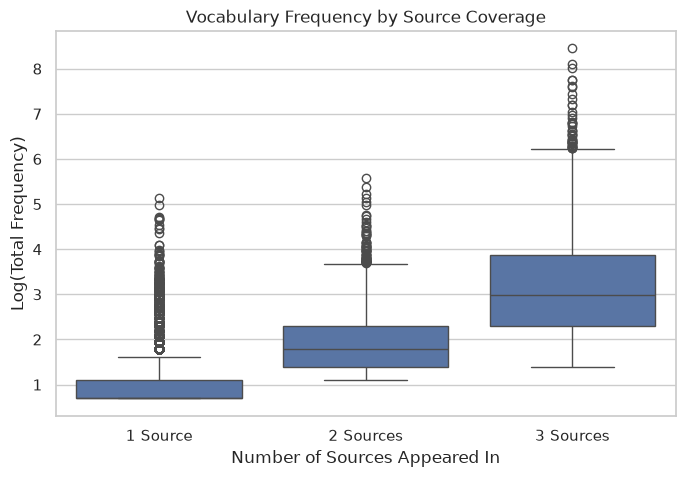

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sources,
    x="source_count",
    y="log_total"
)

plt.xlabel("Number of Sources Appeared In")
plt.ylabel("Log(Total Frequency)")
plt.title("Vocabulary Frequency by Source Coverage")

plt.xticks([0, 1, 2], ["1 Source", "2 Sources", "3 Sources"])

plt.show()

## Finding

Vocabulary frequency increases consistently with source coverage.

Words appearing in only one source have the lowest median frequency, while words appearing across all three sources show substantially higher frequency. This suggests that words shared across different domains are more likely to represent common Hebrew vocabulary.

The larger spread among words appearing in all three sources indicates that this group contains both highly common words and some extremely frequent terms. The presence of many outliers reflects the expected Zipfian distribution of language, where a small number of words occur much more frequently than the majority.

Overall, source coverage appears to be positively associated with vocabulary frequency.

# Limitations and Bias

Although this analysis reveals patterns in the dataset, several limitations should be considered.

- **Corpus representativeness:** The dataset is not a random sample of Hebrew language. It was collected from specific sources (songs, news, and YouTube), which may not represent everyday Hebrew usage.

- **Source imbalance:** The sources have different characteristics and frequencies. For example, YouTube content is more entertainment-oriented, while news vocabulary is influenced by formal and public topics.

- **Frequency interpretation:** Word frequency represents occurrences in this collected corpus, not absolute frequency in the Hebrew language.

- **LLM-assisted labeling:** Semantic labels generated in previous analysis were assigned at the word level without sentence context. A word can have different meanings depending on usage.

- **Validation:** The generated semantic labels were not compared against a manually annotated benchmark dataset.

- **Sampling bias:** Scraped content depends on the availability and popularity of online sources, which may introduce additional biases.

# Conclusion

This analysis found a strong relationship between source coverage and vocabulary frequency. Words appearing across multiple domains tend to occur more frequently, suggesting that cross-domain presence can serve as an indicator of common Hebrew vocabulary.

mThis result aligns with linguistic expectations: highly frequent words are more likely to appear across different contexts, while specialized vocabulary tends to remain concentrated in specific domains.